In [1]:
import time
notebook_start = time.perf_counter()
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker, sys, os, csv, shutil
from scipy.optimize import least_squares
from itertools import chain
from si_units import BAR, KELVIN
from pathlib import Path
from feos.eos import EquationOfState, PhaseDiagram
from feos.pcsaft import PcSaftParameters
from feos.eos.estimator import Estimator, Loss, DataSet, Phase

sys.path.append("..")
import PLOT_SETTINGS as ps

plot_dir = Path("PLOTS")
if plot_dir.exists():
    shutil.rmtree(plot_dir)
plot_dir.mkdir()

mixture         = "CO2-Ar"

In [2]:
def eos_from_kij(kij):
    """Returns equation of state (PC-SAFT) for current kij."""
    global parameters
    p = PcSaftParameters.new_binary(parameters.pure_records, kij)
    return EquationOfState.pcsaft(p)

def cost(kij, estimator):
    """Calculates cost function for current parameters."""
    return estimator.cost(eos_from_kij(kij))

def components(mixture):
    global comp1, comp2
    comp1, comp2 = mixture.split("-")
    
    return comp1, comp2

In [3]:

def VLE_PLOT(mixture, data, cols, temperature, kij):

    comp1, comp2    = components(mixture)
    isotherm        = data[data[cols["T"]] == temperature]
    
    if isotherm.empty:
        raise ValueError(f"No data available for T = {temperature} K")

    fig, ax = ps.plot_init()
    i = 0
 
    # Experimental data
    if isotherm[cols["Comp"]].iloc[0] == comp2:
        ax.plot(1-isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

        ax.plot(1-isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markeredgewidth=ps.markeredgewidth,)
    else:
        ax.plot(isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

        ax.plot(isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markeredgewidth=ps.markeredgewidth,)

    # PC-SAFT predictions
    vle = PhaseDiagram.binary_vle(eos_from_kij(kij),temperature * KELVIN, npoints=100)

    ax.plot(vle.vapor.molefracs[:, 1], vle.vapor.pressure / BAR,
        color='red', linewidth=ps.linewidth, linestyle="-",
        label=fr"PC-SAFT ($k_{{ij}} = {kij:.3f}$)")

    ax.plot(vle.liquid.molefracs[:, 1], vle.liquid.pressure / BAR,
        color='blue', linewidth=ps.linewidth, linestyle="-")

    ax.minorticks_on()
    ymax = (vle.liquid.pressure / BAR).max()
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    
    if ymax > 140:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    else:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

    ax.set_xlabel(r"$x_{\mathrm{CO_2}}$, $y_{\mathrm{CO_2}}$", fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$P$ / [bar]", fontsize=ps.label_fontsize)
    ax.set_xlim(min(vle.vapor.molefracs[:, 1].min(), vle.liquid.molefracs[:, 1].min())- 0.1, 1.1)
    ax.set_ylim( (vle.liquid.pressure / BAR).min()/1.3, (vle.liquid.pressure / BAR).max() * 1.3)

    ps.style_legend(ax,loc='upper right',ncol=1,borderaxespad=1.0,frame=False)

    legend = ax.get_legend()
    for handle in legend.legend_handles:
        handle.set_color("black")
        handle.set_markerfacecolor("black")
        handle.set_markeredgecolor("black")
        
    ps.save_plot(fig, f"vle_T{int(temperature)}K_kij{kij:.3f}")


In [4]:
parameters  = PcSaftParameters.from_json(["argon", "carbon dioxide"], "../parameters_08.json")
pcsaft = EquationOfState.pcsaft(parameters)
parameters

|component|molarweight|$m$|$\sigma$|$\varepsilon$|$\mu$|$Q$|$\kappa_{AB}$|$\varepsilon_{AB}$|$N_A$|$N_B$|$N_C$|
|-|-|-|-|-|-|-|-|-|-|-|-|
|argon|39.962|1|3.37751|117.80903|-|-|-|-|0|0|0|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|-|-|-|-|0|0|0|

In [5]:
data    = pd.read_csv("EXP_DATA_CO2_AR.csv", delimiter=",")
cols = {
    "P": data.columns[0],
    "x1": data.columns[1],
    "y1": data.columns[2],
    "T": data.columns[3],
    'Comp': data.columns[5]
}

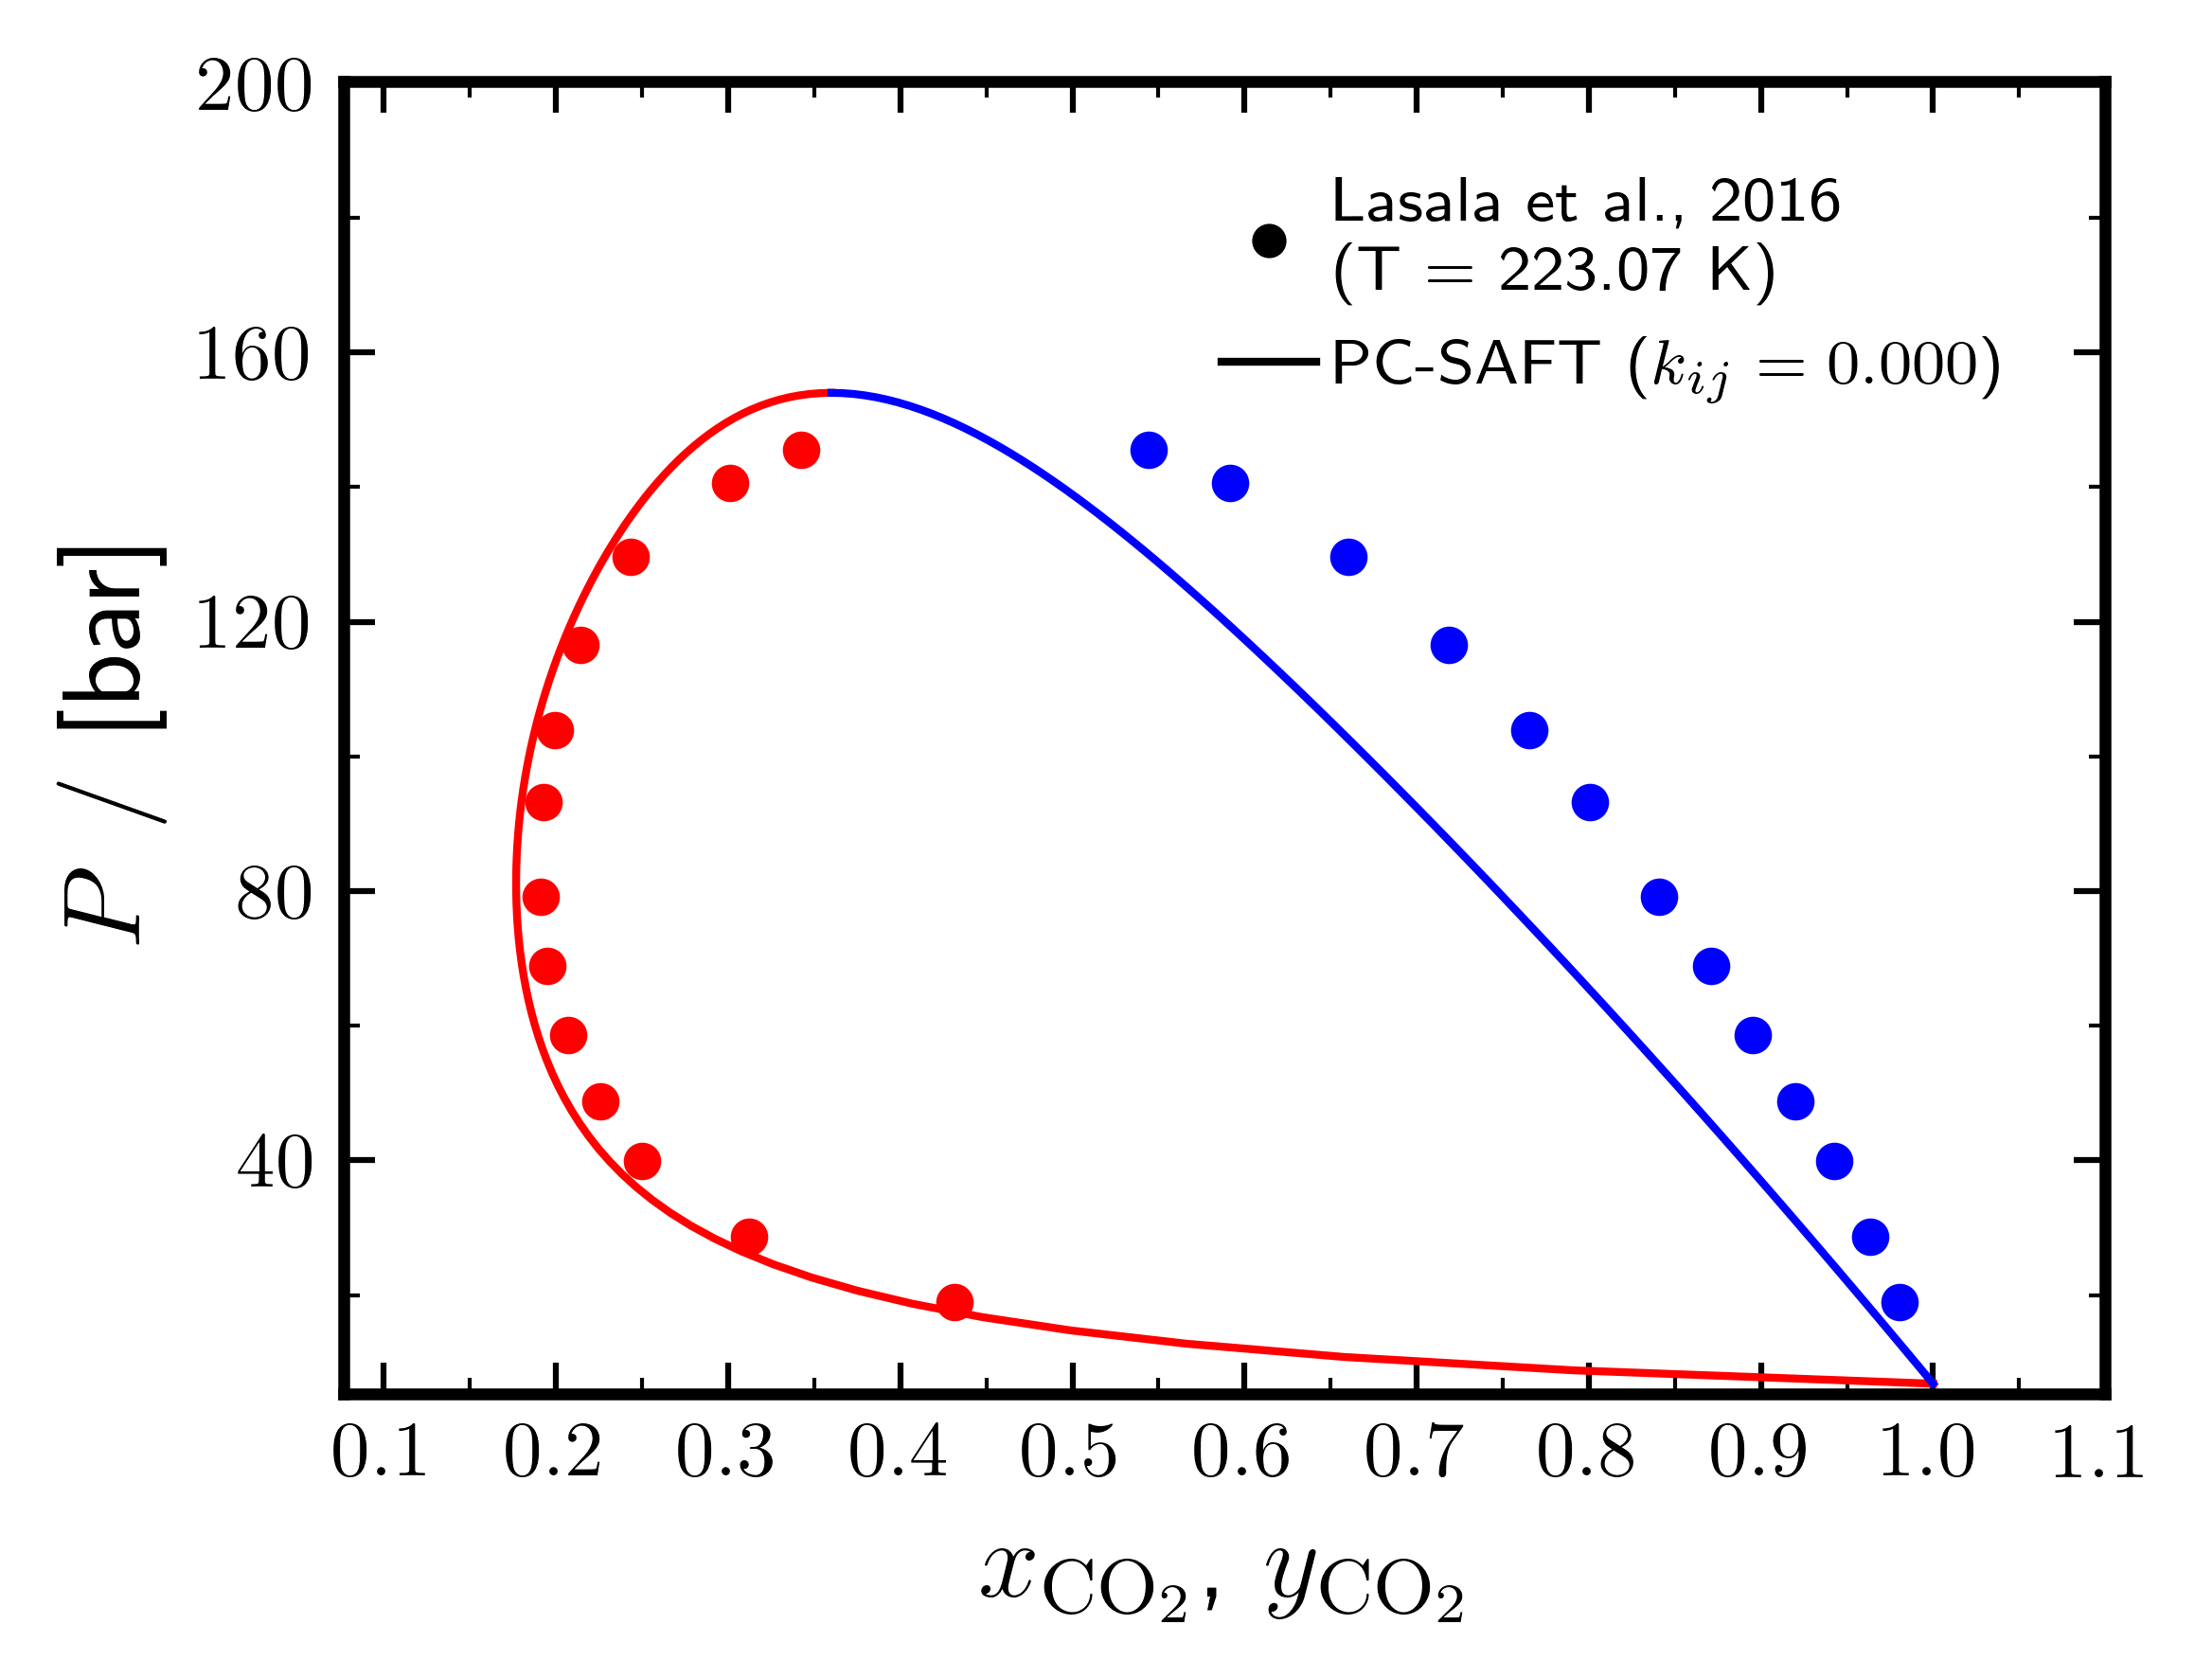

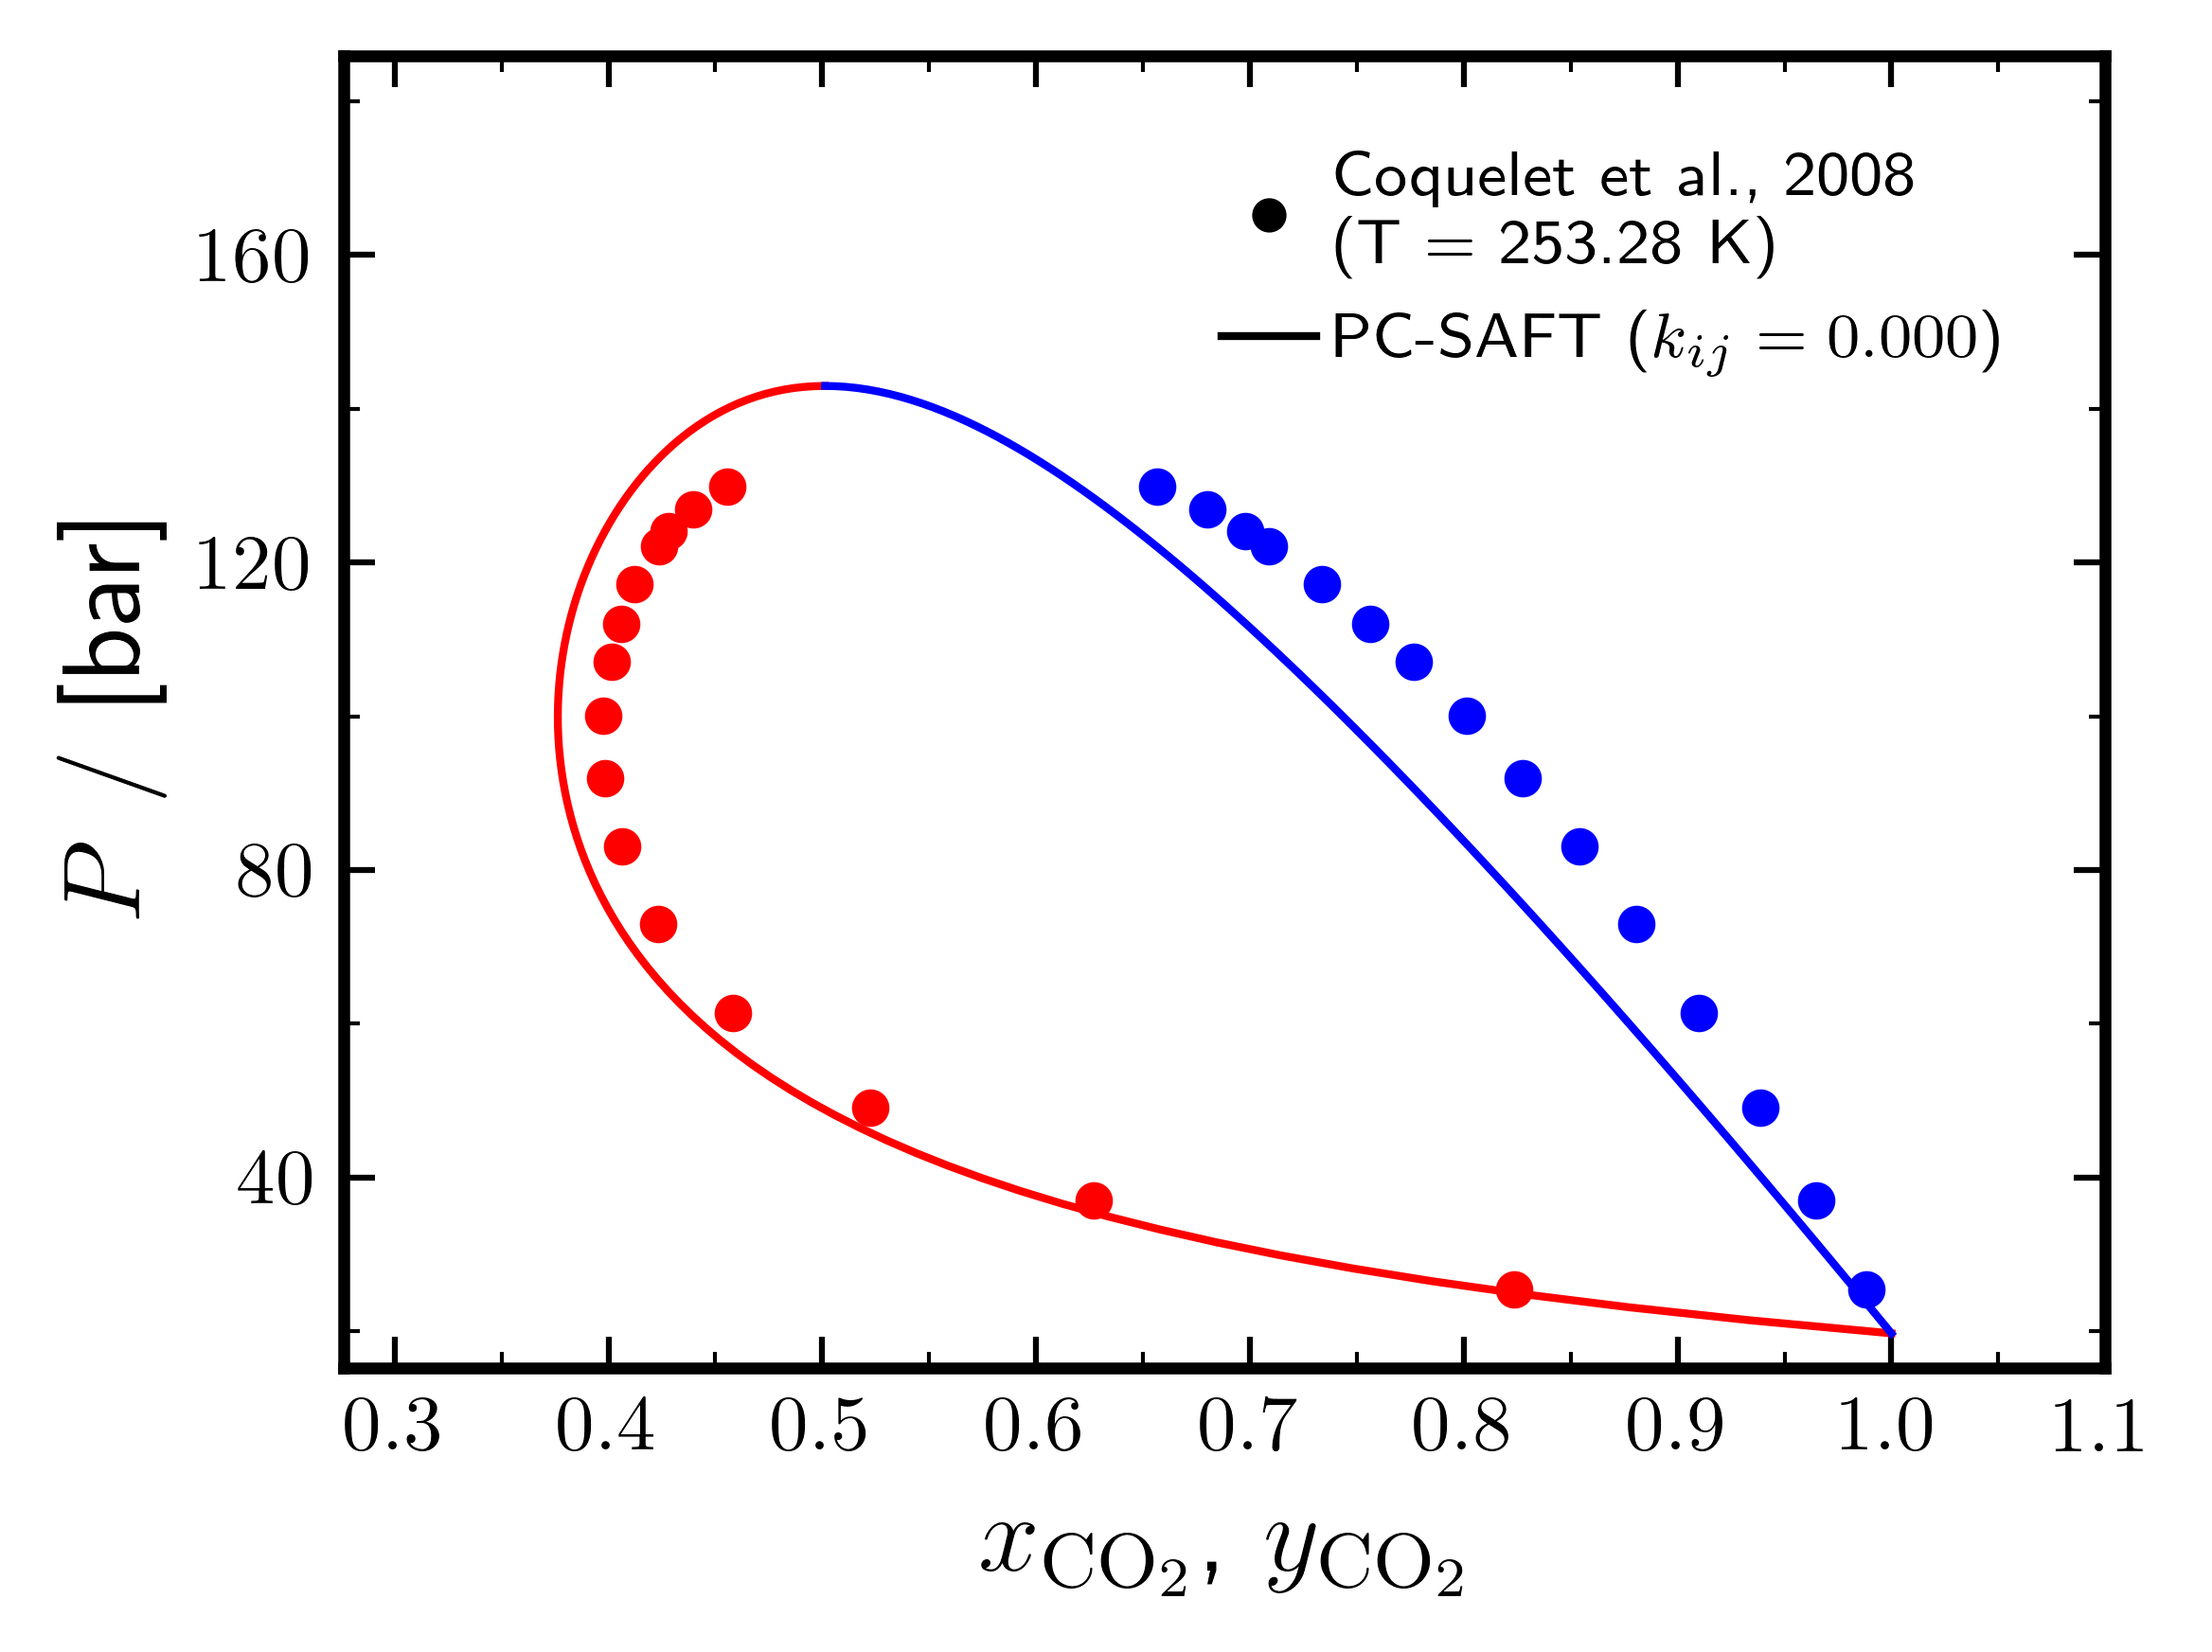

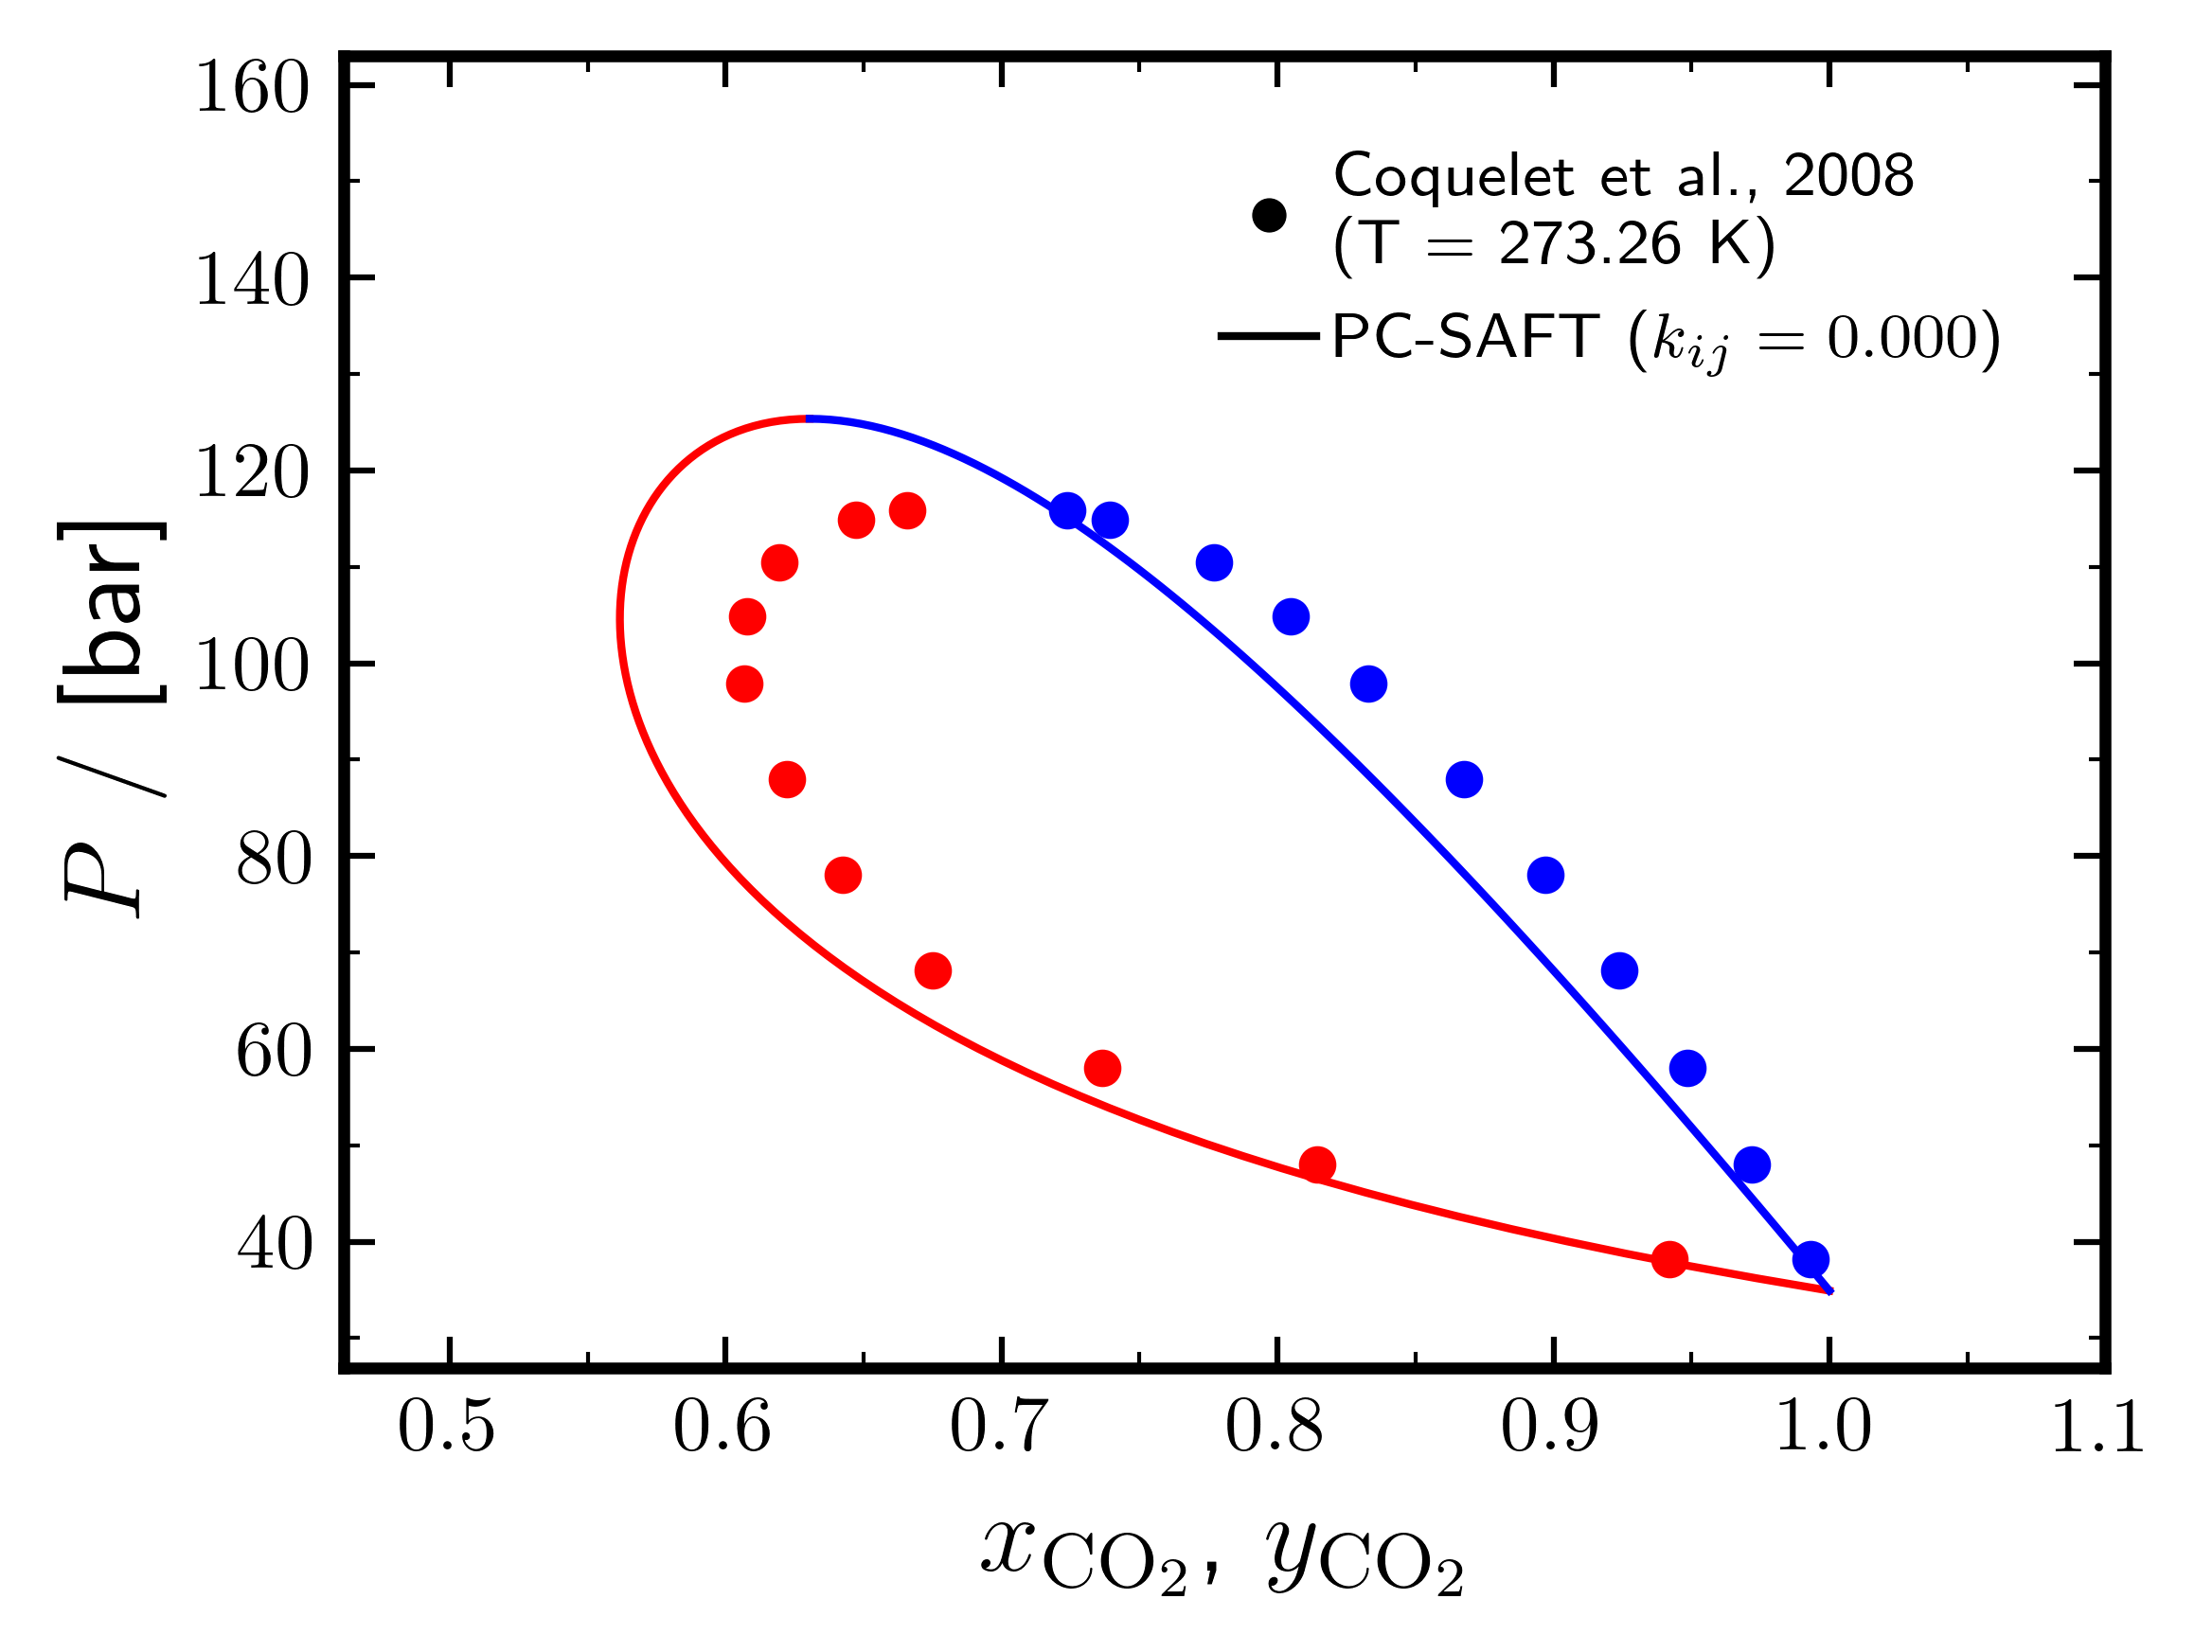

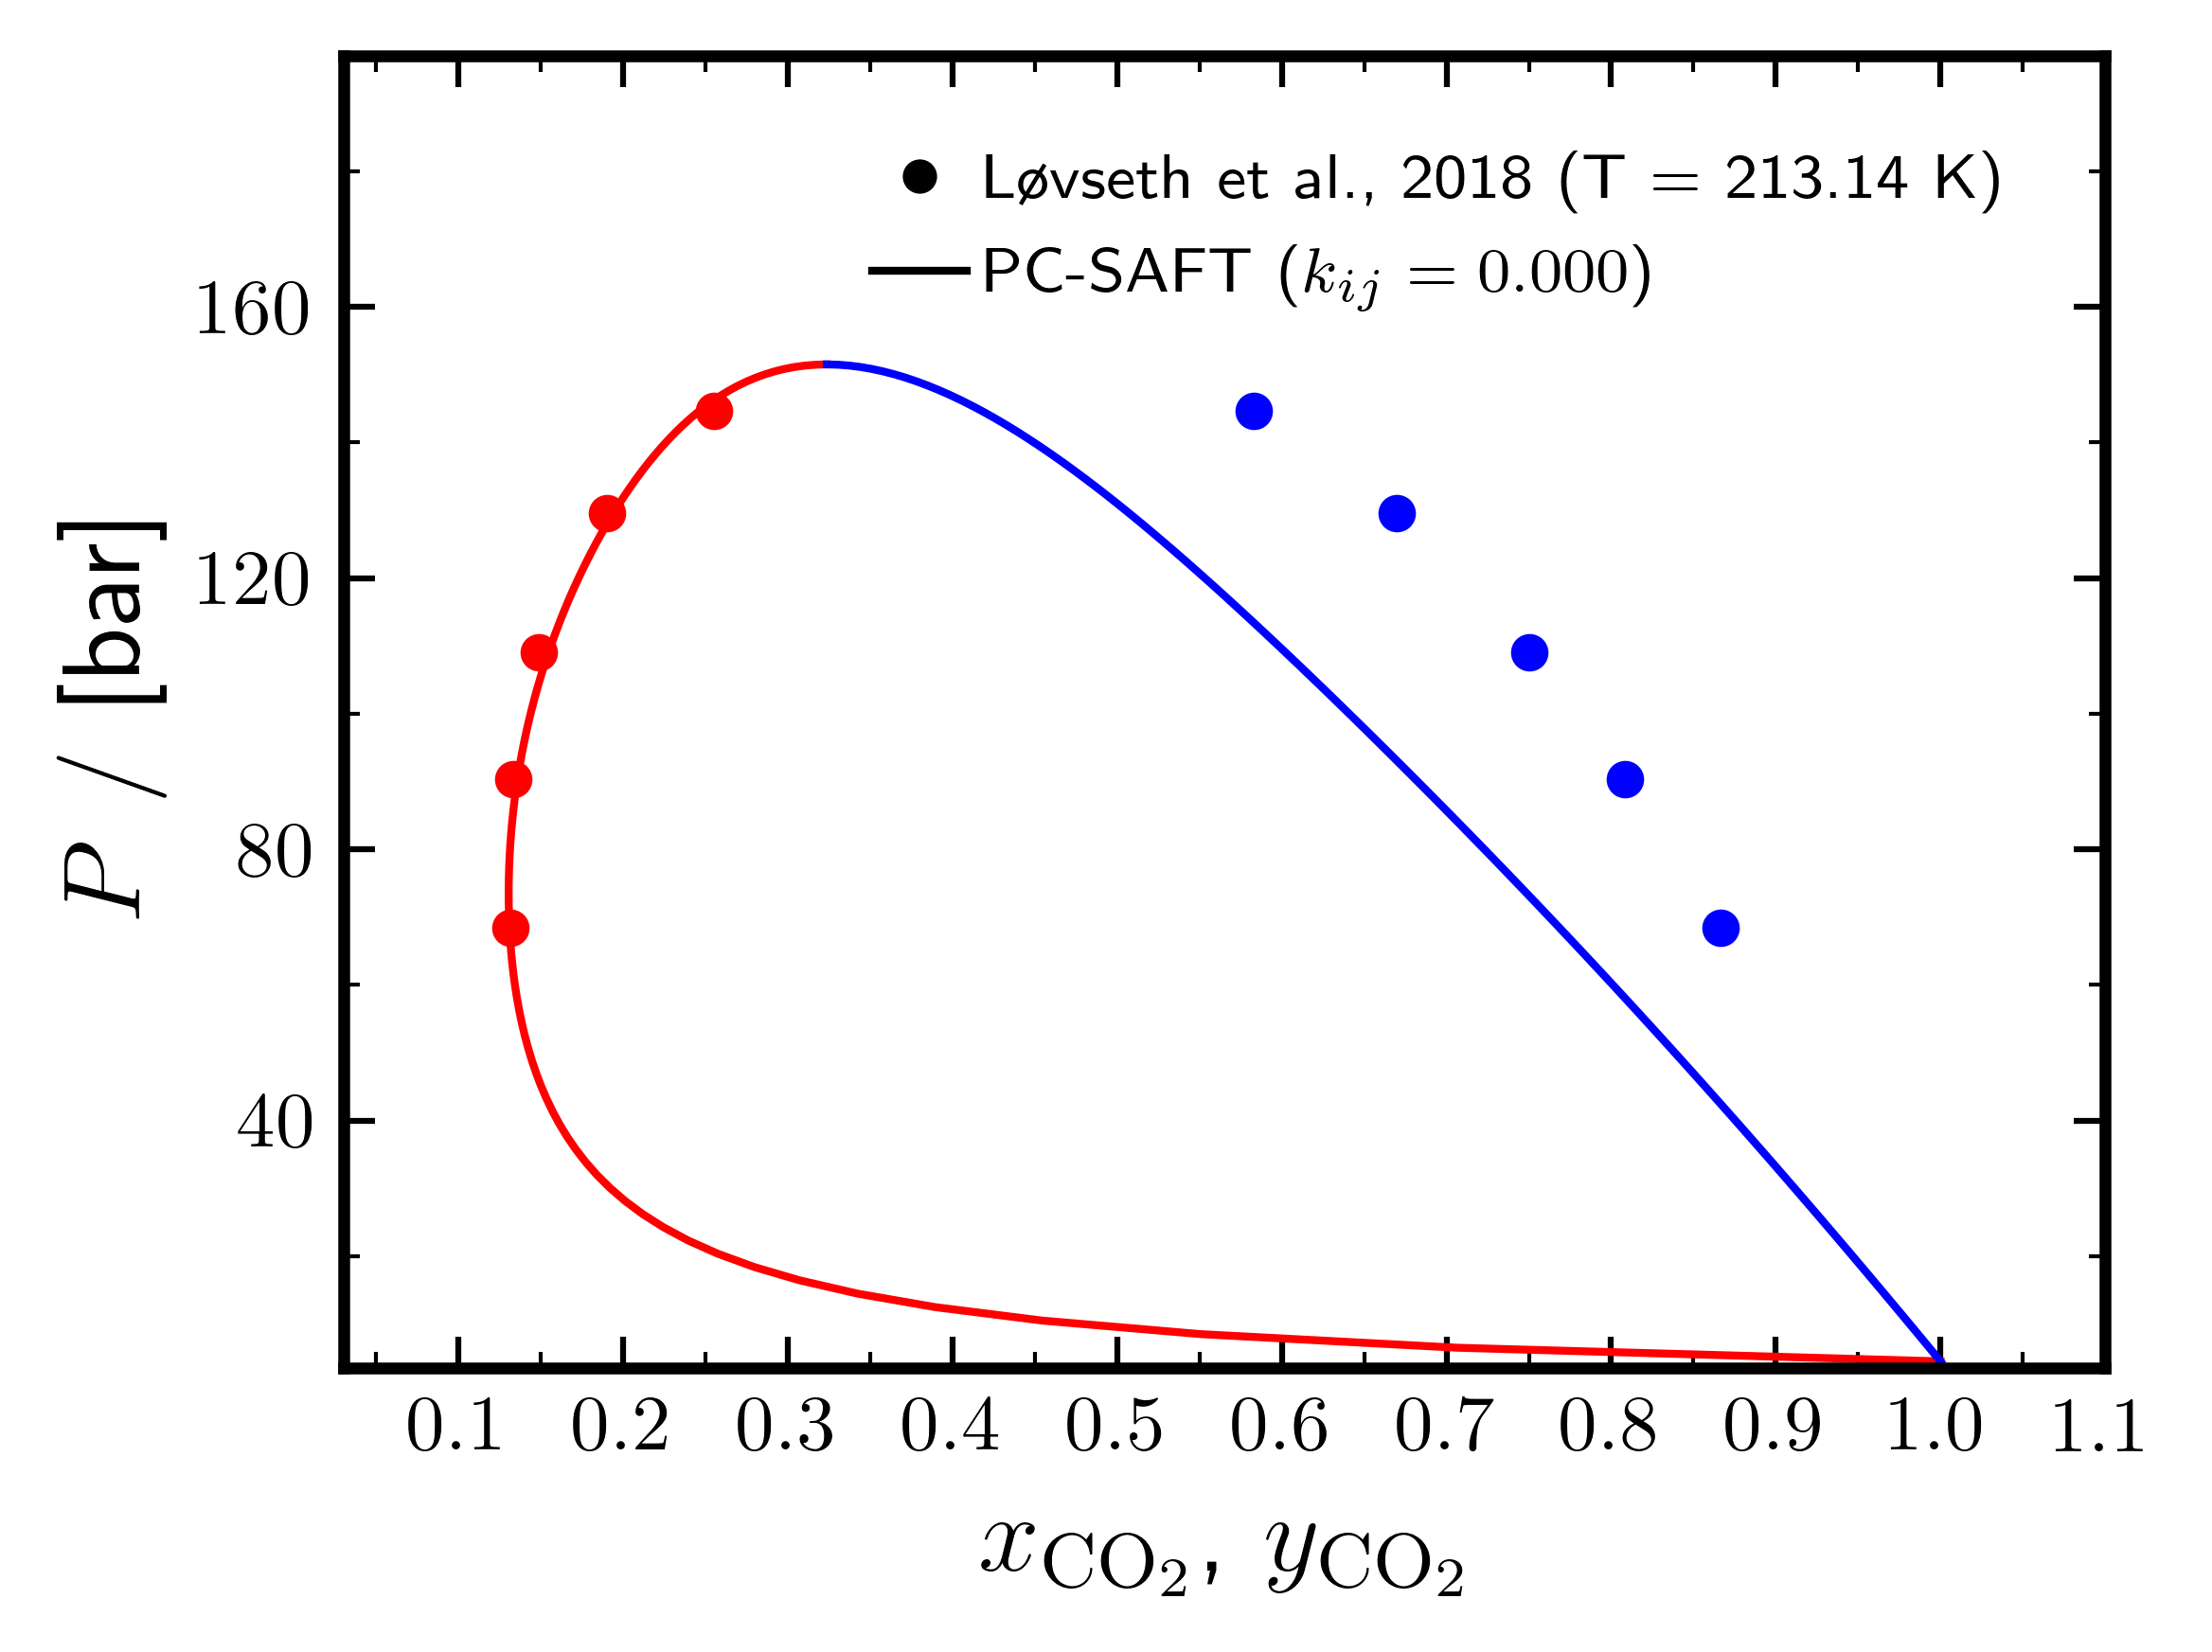

ValueError: No data available for T = nan K

In [6]:
for T in data[cols["T"]].unique():
    VLE_PLOT(mixture, data, cols, T, 0)
    plt.show()

In [ ]:
kij_distance = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
    
    isotherms = [
        DataSet.binary_phase_diagram(T*KELVIN, isotherm[cols["P"]].values * BAR, isotherm[cols["x1"]].values,
            isotherm[cols["y1"]].values,npoints=100)]

    estimator = Estimator(isotherms, weights=[1], losses=[Loss.linear()])
    
    fitted_kij = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator,), verbose=2).x
    
    kij_distance.append(fitted_kij[0])

    mard_distance = estimator.mean_absolute_relative_difference(eos_from_kij(fitted_kij)) * 100

    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["distance", T, fitted_kij[0], mard_distance.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij[0]:.6f}\033[0m")
    
    print(f"MARD (distance,   k_ij = {fitted_kij[0]:>6.4}) = {mard_distance.mean():>8.4} %")

In [ ]:
for T, kij in zip(data[cols["T"]].unique(), kij_distance):
    VLE_PLOT(mixture, data, cols, T, kij)
    plt.show()

In [ ]:
kij_mu = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
        
    isotherms = [
        DataSet.binary_vle_chemical_potential(np.array([T]*len(isotherm)) *KELVIN, 
            isotherm[cols["P"]].values * BAR, isotherm[cols["x1"]].values,
            isotherm[cols["y1"]].values,)]
    
    estimator_mu = Estimator(isotherms, weights=[1]*3, losses=[Loss.linear()]*3)

    fitted_kij_mu = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator_mu,), verbose=2).x

    kij_mu.append(fitted_kij_mu[0])

    mard_mu = estimator_mu.mean_absolute_relative_difference(eos_from_kij(fitted_kij_mu)) * 100

    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["chemical potential", T, fitted_kij_mu[0], mard_mu.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij_mu[0]:.6f}\033[0m")
    print(f"MARD (chem. pot., k_ij = {fitted_kij_mu[0]:>6.4}) = {mard_mu.mean():>8.4} %")

In [ ]:
for T, kij in zip(data[cols["T"]].unique(), kij_mu):
    VLE_PLOT(mixture, data, cols, T, kij)
    plt.show()

In [ ]:
kij_pressure = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]

    isotherms = [[DataSet.binary_vle_pressure(np.array([T]*len(isotherm))*KELVIN, 
                isotherm[cols["P"]].values * BAR, isotherm[cols["x1"]].values,Phase.Liquid)]]
    
    estimator_p = Estimator(list(chain.from_iterable(isotherms)), weights=[1]*6, losses=[Loss.linear()]*6)
    
    try:
        res = least_squares(cost, initial_kij, bounds=(-1, 1), args=(estimator_p,), verbose=2)

        kij_value = float(np.atleast_1d(res.x)[0])
        kij_pressure.append(kij_value)

        mard_value = float(estimator_p.mean_absolute_relative_difference(
            eos_from_kij(np.array([kij_value]))) * 100)

    except Exception as e:
        print("Optimization failed:", e)
        kij_value = np.nan
        kij_pressure.append(np.nan)
        mard_value = np.nan
    
    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["pressure", T, kij_value, mard_value])

    print(f"\033[1mOptimized kij value at T = {T} K: {kij_value:.6f}\033[0m")
    print(f"MARD (pressure,   k_ij = {kij_value:>6.4}) = {mard_value:>8.4} %")

In [ ]:
for T, kij in zip(data[cols["T"]].unique(), kij_pressure):
    try:
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()
    except Exception as e:
        print(f"Error plotting VLE for T={T} K and kij={kij}: {e}")
        plt.close()
        continue

In [ ]:
## KIJ Interpolation/Extrapolation

T_vals      = np.linspace(210, 280, 200)
df_KIJ      = pd.read_csv("PLOTS/kij_all.csv")
idx         = df_KIJ.groupby("Temperature_[K]")["MARD_percentage"].idxmin()
df_best_kij = df_KIJ.loc[idx].reset_index(drop=True)

print(df_best_kij)

In [ ]:
def poly_to_string(coeffs, var="T", name="k_ij"):
    """
    Build a readable polynomial string from np.polyfit coeffs.
    coeffs are in descending powers: [c_n, ..., c_1, c_0]
    """
    deg     = len(coeffs) - 1
    terms   = []
    for i, coef in enumerate(coeffs):
        power = deg - i
        if power == 0:
            terms.append(f"{coef:.6e}")
        elif power == 1:
            terms.append(f"({coef:.6e})*{var}")
        else:
            terms.append(f"({coef:.6e})*{var}^{power}")
    return f"{name}({var}) = " + " + ".join(terms)

def fit_kij_polynomial(df_best_kij, deg=3, T_col="Temperature_[K]", kij_col="kij"):
    """
    Fit kij(T) with a polynomial of degree 'deg'.

    Returns:
      coeffs  : np.ndarray of coefficients (descending powers)
      kij_func: np.poly1d callable function
    """
    T_data      = df_best_kij[T_col].to_numpy(dtype=float)
    kij_data    = df_best_kij[kij_col].to_numpy(dtype=float)

    # sort by temperature
    order       = np.argsort(T_data)
    T_data      = T_data[order]
    kij_data    = kij_data[order]

    coeffs      = np.polyfit(T_data, kij_data, deg=deg)
    kij_func    = np.poly1d(coeffs)

    print("\nFitted function:")
    print(poly_to_string(coeffs, var="T", name="k_ij"))
    print("\nnp.poly1d form:\n", kij_func)

    return coeffs, kij_func, T_data, kij_data

In [ ]:
deg = 3 # change as needed
coeffs, kij_func, T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=deg)

In [ ]:
nfit    = 1000
T_fit   = np.linspace(T_data.min(), T_data.max(), nfit)
kij_fit = kij_func(T_fit)

fig1, ax1 = ps.plot_init()

ax1.plot(df_best_kij["Temperature_[K]"], df_best_kij["kij"],linestyle="",
    linewidth=ps.linewidth,marker=ps.markers[0],markersize=ps.markersize,
    markeredgewidth=ps.markeredgewidth,color=ps.colors[0],
    label=r"$k_{ij}$ from epxerimental data")

ax1.plot(T_fit,kij_fit,color='k',linewidth=ps.linewidth,
   label = rf"{deg}$^{{\mathrm{{rd}}}}$-order polynomial fit")

ax1.set_xlabel(r"$T\,/\, \mathrm{[K]}$", fontsize=ps.label_fontsize)
ax1.set_ylabel(r"$k_{ij}\, / \, [-]$", fontsize=ps.label_fontsize)

ps.style_legend(ax1,loc='upper right',ncol=1,borderaxespad=1.0,frame=False)

ax1.minorticks_on()
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ps.save_plot(fig1, f"kij_{mixture.replace('-','-')}_vs_T")
plt.show()

In [ ]:
notebook_end = time.perf_counter()
print(f"Total notebook runtime: {notebook_end - notebook_start:.2f} s")